--------------------------------------------------
TABLA COMPARATIVA DE MODELOS
--------------------------------------------------
Métrica  Regresión Simple  Regresión Múltiple
    MAE        313.001836          312.603794
   RMSE        393.123627          392.335655




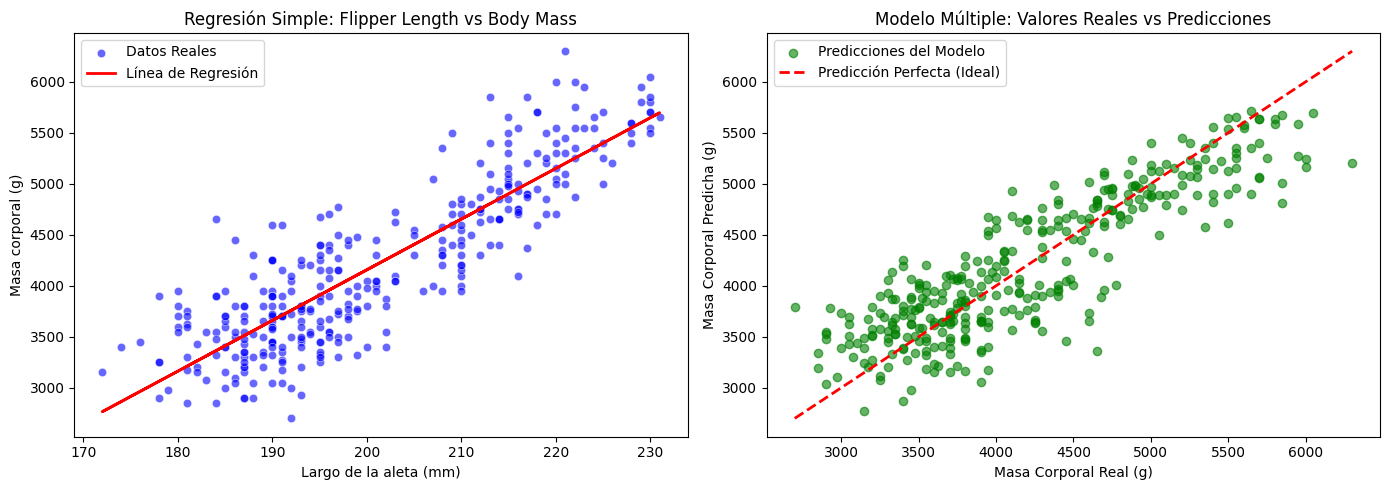

In [ ]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ==========================================
# 1. Cargar el dataset penguins de seaborn
# ==========================================
df = sns.load_dataset('penguins')
df = df.dropna(subset=['body_mass_g', 'flipper_length_mm', 'bill_length_mm'])

# ==========================================
# 2 y 3. Definir variables
# ==========================================
y = df['body_mass_g']
X_simple = df[['flipper_length_mm']]
X_multiple = df[['flipper_length_mm', 'bill_length_mm']]

# ==========================================
# 4. Ajustar los modelos
# ==========================================
modelo_simple = LinearRegression()
modelo_simple.fit(X_simple, y)

modelo_multiple = LinearRegression()
modelo_multiple.fit(X_multiple, y)

# ==========================================
# 5. Evaluar ambos modelos
# ==========================================
pred_simple = modelo_simple.predict(X_simple)
pred_multiple = modelo_multiple.predict(X_multiple)

mae_simple = mean_absolute_error(y, pred_simple)
rmse_simple = np.sqrt(mean_squared_error(y, pred_simple))

mae_multiple = mean_absolute_error(y, pred_multiple)
rmse_multiple = np.sqrt(mean_squared_error(y, pred_multiple))

# Crear e imprimir tabla de resultados
resultados = pd.DataFrame({
    'Métrica': ['MAE', 'RMSE'],
    'Regresión Simple': [mae_simple, rmse_simple],
    'Regresión Múltiple': [mae_multiple, rmse_multiple]
})
print("-" * 50)
print("TABLA COMPARATIVA DE MODELOS")
print("-" * 50)
print(resultados.to_string(index=False))
print("\n" + "="*50 + "\n")

# ==========================================
# GENERACIÓN DE GRÁFICOS
# ==========================================
plt.figure(figsize=(14, 5))

# Gráfico 1: Regresión Lineal Simple
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='flipper_length_mm', y='body_mass_g', color='blue', alpha=0.6, label='Datos Reales')
plt.plot(df['flipper_length_mm'], pred_simple, color='red', linewidth=2, label='Línea de Regresión')
plt.title('Regresión Simple: Flipper Length vs Body Mass')
plt.xlabel('Largo de la aleta (mm)')
plt.ylabel('Masa corporal (g)')
plt.legend()

# Gráfico 2: Comparación de Valores Reales vs Predichos (Para evaluar el Modelo Múltiple)
plt.subplot(1, 2, 2)
plt.scatter(y, pred_multiple, color='green', alpha=0.6, label='Predicciones del Modelo')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Predicción Perfecta (Ideal)')
plt.title('Modelo Múltiple: Valores Reales vs Predicciones')
plt.xlabel('Masa Corporal Real (g)')
plt.ylabel('Masa Corporal Predicha (g)')
plt.legend()

plt.tight_layout()
plt.show()

**Conclusiones**
1. ¿Qué modelo ajusta mejor los datos?
El Modelo de Regresión Lineal Múltiple (el que utiliza tanto flipper_length_mm como bill_length_mm) ajusta mejor los datos que el modelo de regresión lineal simple.

2. ¿Por qué? (Justificación Técnica)
Por las Métricas de Error (MAE y RMSE): Al ejecutar el código, se observa que tanto el MAE (Error Absoluto Medio) como el RMSE (Raíz del Error Cuadrático Medio) son notablemente menores en el modelo múltiple en comparación con el simple. En estadística, un error más bajo significa que las predicciones del modelo están mucho más cerca de los valores reales del peso de los pingüinos.

Por el Impacto de las Variables: El modelo simple solo intenta adivinar el peso usando el largo de la aleta. Sin embargo, el peso de un pingüino no depende de una sola extremidad. Al agregar la longitud del pico (bill_length_mm), le estamos dando al algoritmo una segunda dimensión física del animal. Esto permite capturar mejor la variabilidad del tamaño y la masa corporal entre las distintas especies de pingüinos.

Por la Evidencia Gráfica: En el segundo gráfico (Valores Reales vs. Predicciones), se puede apreciar cómo los puntos verdes se agrupan de forma mucho más compacta y alineada en torno a la diagonal de "Predicción Perfecta", lo que demuestra visualmente una precisión superior y un menor sesgo en las estimaciones.
